<a href="https://colab.research.google.com/github/NataliiaFakas/TFG_BMW/blob/main/2_Random_Forests.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Selección de variables mediante Random Forest**

# Introducción

---

Una vez completado el análisis exploratorio de las variables macroeconómicas y de las
ventas de BMW, en el presente cuaderno se llevará a cabo un análisis de importancia de las
variables mediante un modelo `RandomForestRegressor` de la librería `scikit-learn`.

El objetivo de este análisis es el de complementar el estudio de
correlaciones lineales realizado previamente con una técnica capaz de capturar
relaciones no lineales e interacciones entre variables. Y obtener una
estimación robusta de qué variables macroeconómicas resultan más relevantes para
la construcción del modelo predictivo final de ventas de BMW.

Referencia de la librería utilizada:
[`sklearn.ensemble.RandomForestRegressor`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html#randomforestregressor)

---

## ¿Qué es un Random Forest?

Un **Random Forest** (bosque aleatorio) es un modelo de aprendizaje automático de
tipo *ensemble* (conjunto), basado en la combinación de múltiples árboles de decisión
individuales. En lugar de entrenar un único árbol sobre todo el conjunto de datos, el
algoritmo construye un elevado número de árboles (en este caso, 100), cada uno
entrenado sobre una muestra aleatoria distinta de las observaciones y considerando en
cada división un subconjunto aleatorio de variables.

El resultado final del modelo, en el caso de una tarea de regresión como la presente,
se obtiene **promediando las predicciones individuales de todos los árboles** que
componen el bosque. Esta combinación de aleatoriedad (en los datos y en las variables
consideradas en cada división) y agregación de resultados permite reducir el
sobreajuste (*overfitting*) característico de un único árbol de decisión, mejorando
la capacidad de generalización del modelo.

---

### Funcionamiento del algoritmo:

1. Se generan múltiples submuestras del conjunto de datos original mediante muestreo
   con reemplazo (*bootstrap*).
2. Sobre cada submuestra se entrena un árbol de decisión, en el que cada división
   (*split*) se selecciona a partir de un subconjunto aleatorio de variables
   predictoras, en lugar de considerar todas las variables disponibles.
3. Cada árbol aprende a dividir el espacio de las variables predictoras en regiones
   cada vez más homogéneas respecto a la variable objetivo (en este caso, las ventas
   de BMW), minimizando el error cuadrático medio (MSE) en cada división.
4. La predicción final del modelo para una nueva observación se obtiene promediando
   las predicciones de todos los árboles individuales del bosque.

---

### Importancia de variables

Como subproducto natural de este proceso de entrenamiento, es posible calcular la
**importancia relativa de cada variable predictora**, accesible a través del atributo
`modelo.feature_importances_`. Esta métrica conocida como *Mean Decrease in Impurity*
(MDI), cuantifica para cada variable, la disminución media de la impureza (en
regresión, del error cuadrático medio) que se produce en el conjunto del bosque cada
vez que dicha variable se utiliza para realizar una división.

Cuanto mayor sea esta
disminución acumulada, mayor se considera la relevancia de la variable para explicar
la variable objetivo. Variables cuyo valor de importancia se sitúa próximo a cero
aportan escasa capacidad explicativa dentro del modelo, y son candidatas naturales a
ser descartadas en una versión simplificada del conjunto de predictores.

---

### Razón por la que se opta por esta técnica en el presente estudio

Frente al análisis de correlación de Pearson realizado en el apartado anterior que
únicamente captura relaciones **lineales** entre pares de variables, el Random
Forest presenta las siguientes ventajas:

- Es capaz de capturar **relaciones no lineales** entre las variables macroeconómicas y las ventas de BMW que no se han podido capturar en el análisis anterior.
- Puede detectar **interacciones** entre variables (por ejemplo, el efecto conjunto
  de la inflación y el desempleo), que un análisis bivariante como la correlación no
  contempla.
- No requiere que las variables predictoras estén en la misma escala, lo que resulta
  especialmente conveniente dada la elevada heterogeneidad de magnitudes presente en
  el conjunto de datos (desde valores en torno a 1, como `EUR_USD`, hasta cifras en
  cientos de millones, como `Population_Total`).

No obstante, como se discutirá al interpretar los resultados, esta técnica no está
exenta de limitaciones, particularmente en presencia de variables altamente
correlacionadas entre sí (multicolinealidad), tal y como se identificó en el análisis
de VIF del apartado anterior.

In [ ]:
import pandas as pd

#from google.colab import drive
#drive.mount('/content/drive')

# Variables macro
ruta_macro = "/content/drive/MyDrive/TFG_BMW/datasets/bmw_dataset_variables_macro.csv"

# Ventas anuales BMW
ruta_ventas = "/content/drive/MyDrive/TFG_BMW/datasets/ventas_bmw.csv"

df_macro = pd.read_csv(ruta_macro, sep=",")
df_ventas = pd.read_csv(ruta_ventas, sep=",")

display(df_macro.head())
display(df_ventas.head())

,Year,Unemployment_Rate,GDP_Growth,Deposit_Facility,HICP,Industrial_Production,Retail_Sales_Growth,Consumer_Confidence,Compensation_Per_Employee,Brent_Oil_Price,EUR_USD,Euribor_12M,Population_Total
0,2005,8.9,1.7,1.25,2.18,153.2,0.03,-4.2,31.22,54.57,1.2441,2.19,434585887
1,2006,8.2,3.2,2.50,2.19,147.7,0.04,-3.5,31.95,65.16,1.2556,3.08,436041018
2,2007,7.2,2.9,3.00,2.13,145.5,0.03,-2.1,32.75,72.44,1.3705,4.24,437514477
3,2008,7.1,0.4,2.00,3.30,148.0,0.01,-10.8,33.86,96.94,1.4708,4.63,439074280
4,2009,9.0,-4.4,0.25,0.29,144.5,-0.03,-21.7,34.41,61.74,1.3948,1.31,440467898


,Año,Ventas_BMW_Unidades
0,2005,1126768
1,2006,1185088
2,2007,1276793
3,2008,1202239
4,2009,1068770


In [ ]:
df_ventas = df_ventas.rename(columns={
    "Año": "Year"
})

In [ ]:
data = df_macro.merge(
    df_ventas,
    on="Year",
    how="inner"
)

display(data.head())

,Year,Unemployment_Rate,GDP_Growth,Deposit_Facility,HICP,Industrial_Production,Retail_Sales_Growth,Consumer_Confidence,Compensation_Per_Employee,Brent_Oil_Price,EUR_USD,Euribor_12M,Population_Total,Ventas_BMW_Unidades
0,2005,8.9,1.7,1.25,2.18,153.2,0.03,-4.2,31.22,54.57,1.2441,2.19,434585887,1126768
1,2006,8.2,3.2,2.50,2.19,147.7,0.04,-3.5,31.95,65.16,1.2556,3.08,436041018,1185088
2,2007,7.2,2.9,3.00,2.13,145.5,0.03,-2.1,32.75,72.44,1.3705,4.24,437514477,1276793
3,2008,7.1,0.4,2.00,3.30,148.0,0.01,-10.8,33.86,96.94,1.4708,4.63,439074280,1202239
4,2009,9.0,-4.4,0.25,0.29,144.5,-0.03,-21.7,34.41,61.74,1.3948,1.31,440467898,1068770


Ahora creamos X e Y:

In [ ]:
X = data.drop(columns=["Year", "Ventas_BMW_Unidades"])

y = data["Ventas_BMW_Unidades"]

print(X.shape)
print(y.shape)

(21, 12)
(21,)


In [ ]:
from sklearn.ensemble import RandomForestRegressor

modelo = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

modelo.fit(X, y)

RandomForestRegressor(random_state=42)

In [ ]:
importancias = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": modelo.feature_importances_
})

importancias = importancias.sort_values(
    by="Importancia",
    ascending=False
)

display(importancias)

,Variable,Importancia
7,Compensation_Per_Employee,0.289217
4,Industrial_Production,0.281089
11,Population_Total,0.227091
9,EUR_USD,0.108843
0,Unemployment_Rate,0.019807
8,Brent_Oil_Price,0.019490
10,Euribor_12M,0.018939
2,Deposit_Facility,0.013337
3,HICP,0.012211
1,GDP_Growth,0.004541


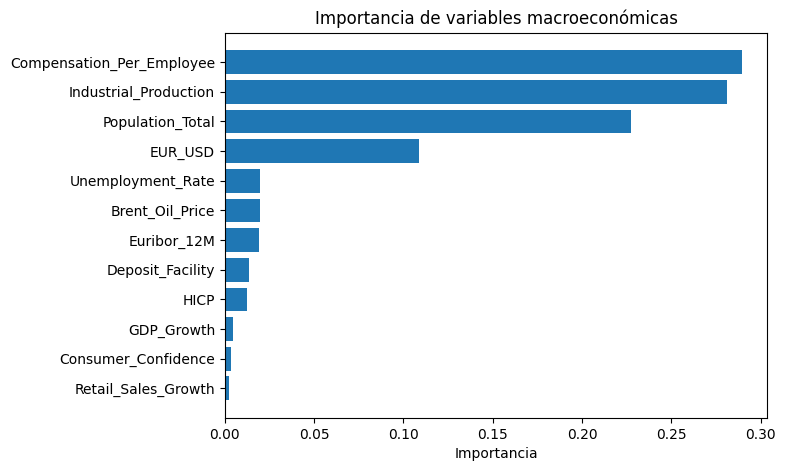

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.barh(
    importancias["Variable"],
    importancias["Importancia"]
)

plt.gca().invert_yaxis()

plt.xlabel("Importancia")
plt.title("Importancia de variables macroeconómicas")

plt.show()



---

## Interpretación de los resultados del Random Forest

Una vez entrenado el modelo `RandomForestRegressor`, se ha obtenido la importancia relativa de cada variable explicativa mediante la métrica **Mean Decrease in Impurity (MDI)**. Esta medida refleja la contribución de cada variable a la reducción del error de predicción a lo largo del conjunto de árboles que forman el bosque aleatorio.

Los resultados pueden obtener valores comprendidos entre 0 y 1. Cuanto más alejado esté el valor de 0, mayor será su importancia relativa para el modelo.

Los resultados obtenidos son los siguientes:

| Variable | Importancia |
|-----------|-----------:|
| Compensation_Per_Employee | 0.289 |
| Industrial_Production | 0.281 |
| Population_Total | 0.227 |
| EUR_USD | 0.109 |
| Unemployment_Rate | 0.020 |
| Brent_Oil_Price | 0.019 |
| Euribor_12M | 0.019 |
| Deposit_Facility | 0.013 |
| HICP | 0.012 |
| GDP_Growth | 0.005 |
| Consumer_Confidence | 0.003 |
| Retail_Sales_Growth | 0.002 |

---

## Variables de gran importancia


### Compensation_Per_Employee

La variable más importante del modelo es la **compensación por empleado**, con una importancia de 0,289.

Este resultado es coherente con la naturaleza del producto analizado. BMW es una marca posicionada en el segmento medio-alto y premium del mercado automovilístico, por lo que el poder adquisitivo de los consumidores desempeña un papel fundamental en la decisión de compra.

Un incremento en la remuneración media de los trabajadores aumenta la capacidad financiera de los hogares, favoreciendo la adquisición de vehículos de mayor valor añadido.

---

### Industrial_Production

La **producción industrial** aparece como la segunda variable más relevante, con una importancia de 0,281.

Esta variable suele considerarse un indicador adelantado de la actividad económica. Un aumento de la producción industrial suele estar asociado a una economía en expansión, mayor inversión empresarial y mejora de las expectativas económicas, factores que favorecen el consumo de bienes duraderos como los automóviles.

---

### Population_Total

La **población total** ocupa la tercera posición con una importancia de 0,227.

Este resultado indica que el tamaño potencial del mercado es un factor relevante para explicar las ventas de BMW. Un mayor número de habitantes implica un mayor número potencial de compradores.

Sin embargo, esta variable debe interpretarse con cautela, ya que presenta una tendencia creciente sostenida a lo largo del tiempo y parte de su importancia podría estar capturando dicha tendencia temporal más que una relación causal directa.

---

### EUR_USD

El **tipo de cambio EUR/USD** presenta una importancia de 0,109.

Las fluctuaciones del tipo de cambio afectan a los costes de producción, al precio de determinados componentes importados y a la competitividad internacional de las empresas europeas.

Aunque BMW desarrolla la mayor parte de su actividad dentro de Europa, la empresa opera en mercados globales y puede verse afectada indirectamente por las variaciones en el valor del euro frente al dólar estadounidense.

---

### Variables de importancia media-baja

Las variables:

- Unemployment_Rate (0,020)
- Brent_Oil_Price (0,019)
- Euribor_12M (0,019)

presentan una contribución reducida pero no despreciable.

La tasa de desempleo influye sobre la confianza y la capacidad de gasto de los consumidores, mientras que el precio del petróleo y el Euribor afectan al coste de utilización y financiación de los vehículos.

No obstante, según el modelo, su capacidad explicativa es claramente inferior a la de los salarios, la producción industrial o la población.

---

### Variables con escasa relevancia

Las siguientes variables obtienen valores de importancia muy próximos a cero:

- Deposit_Facility (0,013)
- HICP (0,012)
- GDP_Growth (0,005)
- Consumer_Confidence (0,003)
- Retail_Sales_Growth (0,002)

Estos resultados sugieren que dichas variables aportan poca información adicional al modelo una vez consideradas las demás variables explicativas. Esto puede deberse a la existencia de correlaciones elevadas con otros predictores o a que sus efectos ya están siendo capturados indirectamente por variables más influyentes como la compensación por empleado o la producción industrial.

---

## Conclusión

Los resultados del Random Forest indican que las variables con mayor capacidad para explicar las ventas de BMW en Europa son:

1. **Compensation_Per_Employee**
2. **Industrial_Production**
3. **Population_Total**
4. **EUR_USD**

Estas variables concentran aproximadamente el **90 % de la importancia total del modelo**, lo que sugiere que el poder adquisitivo de los consumidores, el ciclo económico, el tamaño del mercado potencial y las condiciones macroeconómicas internacionales son los factores que mejor explican la evolución histórica de las ventas de BMW.